<a href="https://colab.research.google.com/github/zlwym/Mann_Zoe_LabTask/blob/main/labtask04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [45]:
df = pd.read_csv("youtube_videos.csv")

In [46]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [47]:
df["subscribers"]

,subscribers
0,441016
1,25339
2,2398429
3,498144
4,30039
...,...
205,13428
206,10005
207,483919
208,11937


In [48]:
minmax_scaler = MinMaxScaler()

In [49]:
df["subscribers_minmax"] = minmax_scaler.fit_transform(df[["subscribers"]])

In [50]:
df["subscribers"].describe()

,subscribers
count,2.100000e+02
mean,1.005263e+06
std,2.063624e+06
min,5.624000e+03
25%,2.544875e+04
50%,1.359100e+05
75%,4.862028e+05
max,7.763623e+06


In [51]:
standard_scaler = StandardScaler()

In [52]:
df["views_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [53]:
df[["views", "views_zscore"]]

,views,views_zscore
0,228102,-0.262478
1,25078,-0.428777
2,1323949,0.635144
3,187752,-0.295529
4,12583,-0.439012
...,...,...
205,6441,-0.444043
206,4755,-0.445424
207,104852,-0.363434
208,3026,-0.446840


In [54]:
df[["views", "views_zscore"]].describe()

,views,views_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [55]:
robust_scaler = RobustScaler()

In [56]:
df["comments_minmax"] = minmax_scaler.fit_transform(df[["comments"]])
df["comments_standard"] = standard_scaler.fit_transform(df[["comments"]])
df["comments_robust"] = robust_scaler.fit_transform(df[["comments"]])

In [57]:
df[["comments", "comments_robust", "comments_standard", "comments_minmax"]].describe()

,comments,comments_robust,comments_standard,comments_minmax
count,210.000000,210.000000,2.100000e+02,210.000000
mean,6545.333333,1.695177,1.268826e-17,0.054907
std,15276.060688,4.273323,1.002389e+00,0.128226
min,4.000000,-0.134695,-4.292313e-01,0.000000
25%,105.750000,-0.106231,-4.225547e-01,0.000854
50%,485.500000,0.000000,-3.976361e-01,0.004042
75%,3680.500000,0.893769,-1.879856e-01,0.030860
max,119138.000000,33.191832,7.388142e+00,1.000000


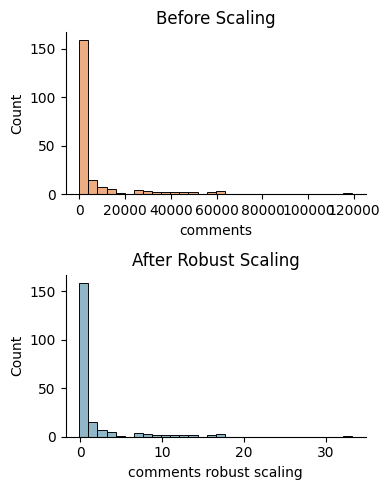

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["comments"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before Scaling")
axes[0].set_xlabel("comments")

sns.histplot(df["comments_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After Robust Scaling")
axes[1].set_xlabel("comments robust scaling")

sns.despine()
plt.tight_layout()
plt.show()

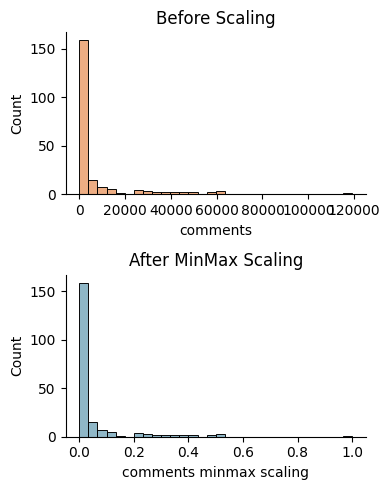

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["comments"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before Scaling")
axes[0].set_xlabel("comments")

sns.histplot(df["comments_minmax"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After MinMax Scaling")
axes[1].set_xlabel("comments minmax scaling")

sns.despine()
plt.tight_layout()
plt.show()

In [64]:
df["views_log"] = np.log1p(df["views"])

<Axes: xlabel='views_log', ylabel='Count'>

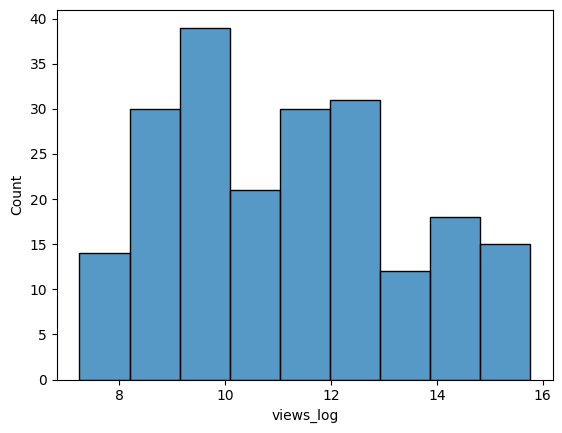

In [65]:
sns.histplot(df["views_log"])

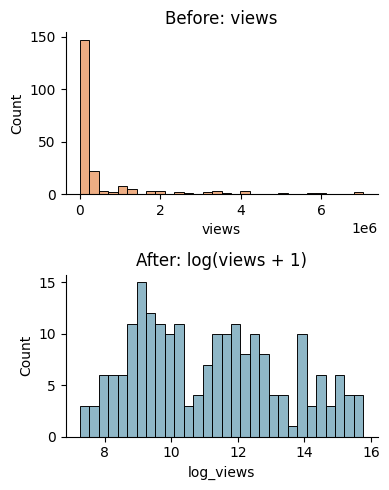

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_log"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(views + 1)")
axes[1].set_xlabel("log_views")

sns.despine()
plt.tight_layout()
plt.show()

In [73]:
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

In [69]:
df["shares"].describe()

,shares
count,210.000000
mean,3947.052381
std,8731.782974
min,5.000000
25%,65.500000
50%,335.000000
75%,2243.250000
max,48004.000000


In [83]:
bins = [0, 500, 10000, float("inf")]
labels = ["Boring", "Engaging", "Controversial"]

df["comments_bin"] = pd.cut(df["comments"], bins=bins, labels=labels)

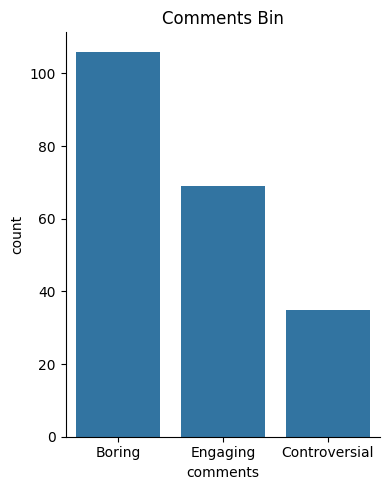

In [84]:
fig, ax = plt.subplots(figsize=(4, 5))
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

sns.countplot(data=df,
              x="comments_bin",
              ax=ax)
ax.set_title("Comments Bin")
ax.set_xlabel("comments")
ax.set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

In [85]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [86]:
encoder = OrdinalEncoder(categories=[['Mid', 'Small', 'Large']])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)
df[["channel_tier_encoded"]]

,channel_tier_encoded
0,0
1,1
2,2
3,0
4,1
...,...
205,1
206,1
207,0
208,1


In [87]:
dummyVars = pd.get_dummies(df["category"], prefix="is")
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [88]:
df = pd.concat([df, dummyVars], axis=1)
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,views_log,comments_bin,duration_bin,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,12.337553,Engaging,medium,0,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,10.129786,Boring,medium,1,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,14.096130,Controversial,medium,2,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,12.142883,Engaging,medium,0,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,9.440181,Boring,long,1,False,False,False,True,False,False


In [89]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)
df["caps_count"]

,caps_count
0,3
1,1
2,0
3,0
4,4
...,...
205,3
206,2
207,0
208,2


In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

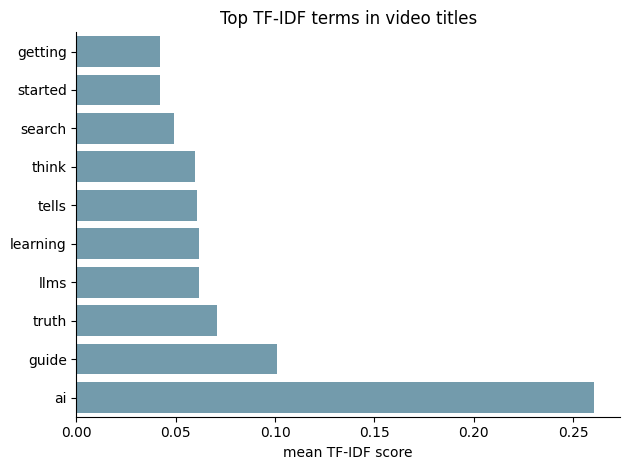

In [91]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [92]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"] * df["duration_minutes"])

In [93]:
df["retention_rate"]

,retention_rate
0,0.398058
1,0.535375
2,0.415428
3,0.483146
4,0.396453
...,...
205,0.469772
206,0.289126
207,0.495605
208,0.528993
